# Speech/silence discrimantion approach using Binary Search algorithm

This notebook covers the pipeline for the process.

Step by step execution below:

# 1. Modules import and constant declarations.

In [1]:
%matplotlib inline
import os
import wave
import math
import numpy as np
import matplotlib.pyplot as pyplot

# --- CONSTANTS ---
FRAME_SIZE = 25
FRAME_STEP = 10
MIN_SILENCE = 200

parent_dir = os.path.abspath('..')

# 2. Signal processing and value calculations

In [2]:
def readAudio(path):
    with wave.open(path, 'rb') as WavFile:
        SampleRate = WavFile.getframerate()            
        SampleAmount = WavFile.getnframes()            
        RawData = WavFile.readframes(SampleAmount)    
        Signal = np.frombuffer(RawData, dtype=np.int16)
        MaxAmp = np.max(np.abs(Signal))
        if MaxAmp > 0:
            SignalNormalized = Signal / MaxAmp
        else:
            SignalNormalized = Signal                  
        Duration = SampleAmount / SampleRate
        TimeAxis = np.linspace(0, Duration, num=SampleAmount)
        return SignalNormalized, SampleRate, TimeAxis

def frameWindow(SignalNormalized, SampleRate):
    FrameLength = int(SampleRate * (FRAME_SIZE / 1000))     
    FrameStep = int(SampleRate * (FRAME_STEP / 1000))       
    SignalLength = len(SignalNormalized)
    if (SignalLength < FrameLength):
        FrameNumber = 1
    else:
        FrameNumber = 1 + int(np.floor((SignalLength - FrameLength) / FrameStep))
    Window = np.hamming(FrameLength)
    Frames = []
    for i in range(FrameNumber):
        StartID = i * FrameStep
        EndID = StartID + FrameLength
        CurrentFrame = SignalNormalized[StartID:EndID]
        if (len(CurrentFrame) < FrameLength):
            PaddingLength = FrameLength - len(CurrentFrame)
            CurrentFrame = np.pad(CurrentFrame, (0, PaddingLength), 'constant')
        WindowedFrame = CurrentFrame * Window
        Frames.append(WindowedFrame)
    return np.array(Frames)

def calculate_STE(Frames):
    return np.sum(Frames ** 2, axis=1)

def calculate_MA(Frames):
    return np.sum(np.abs(Frames), axis=1)

def calculate_ZCR(Frames):
    Signs = np.sign(Frames)
    SignChanges = np.abs(np.diff(Signs, axis=1)) > 0
    return np.sum(SignChanges, axis=1)

# 3. Smoothing logic and boundary parsing

In [3]:
def smoothingLogic(SpeechFrames):
    MinSilenceFrames = MIN_SILENCE // FRAME_STEP    
    SmoothedSpeech = np.copy(SpeechFrames)
    InSilence = False
    SilenceStart = 0
    for i in range (len(SmoothedSpeech)):
        if not SmoothedSpeech[i] and not InSilence:
            InSilence = True
            SilenceStart = i
        elif SmoothedSpeech[i] and InSilence:
            InSilence = False
            SilenceLength = i - SilenceStart
            if SilenceLength < MinSilenceFrames:
                SmoothedSpeech[SilenceStart:i] = True
    return SmoothedSpeech

def read_lab_boundaries(lab_path):
    raw_segments = []
    with open(lab_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                try:
                    start_time = float(parts[0])
                    end_time = float(parts[1])
                    label = parts[2].lower()
                    if label in ['v', 'uv']:
                        raw_segments.append([start_time, end_time])
                except ValueError:
                    continue
    if not raw_segments:
        return []
    merged_boundaries = []
    current_start = raw_segments[0][0]
    current_end = raw_segments[0][1]
    for i in range(1, len(raw_segments)):
        next_start = raw_segments[i][0]
        next_end = raw_segments[i][1]
        if abs(next_start - current_end) < 0.001:
            current_end = next_end
        else:
            merged_boundaries.append([current_start, current_end])
            current_start = next_start
            current_end = next_end
    merged_boundaries.append([current_start, current_end])
    return merged_boundaries

def get_boundaries_from_bool(speech_frames, frame_step_s):
    boundaries = []
    in_speech = False
    start_time = 0
    for i, is_speech in enumerate(speech_frames):
        if is_speech and not in_speech:
            start_time = i * frame_step_s
            in_speech = True
        elif not is_speech and in_speech:
            end_time = i * frame_step_s
            boundaries.append([round(start_time, 3), round(end_time, 3)])
            in_speech = False
    if in_speech:
        end_time = len(speech_frames) * frame_step_s
        boundaries.append([round(start_time, 3), round(end_time, 3)])
    return boundaries

# 4. Binary search application in narrowing down boundary, evaluation and visualization

In [6]:
def find_shared_threshold_binary_search(feature_arrays, true_boundaries_list, frame_step_ms=10, min_silence_ms=200):
    total_target_frames = 0
    for true_boundaries in true_boundaries_list:
        duration_s = sum([end - start for start, end in true_boundaries])
        total_target_frames += int(duration_s / (frame_step_ms / 1000.0))
    
    low = min([np.mean(f) for f in feature_arrays]) * 0.05
    high = max([np.max(f) for f in feature_arrays])
    best_T = low
    closest_diff = float('inf')
    
    for _ in range(50): 
        mid = (low + high) / 2.0
        total_current_frames = 0
        for feature_array in feature_arrays:
            raw_speech = feature_array > mid
            smoothed_speech = smoothingLogic(raw_speech) 
            total_current_frames += np.sum(smoothed_speech)
            
        diff = abs(total_current_frames - total_target_frames)
        if diff < closest_diff:
            closest_diff = diff
            best_T = mid
            
        if total_current_frames > total_target_frames:
            low = mid
        elif total_current_frames < total_target_frames:
            high = mid
        else:
            break
    return best_T

def evaluate_and_print_terminal(results_dict, shared_T):
    print(f"\n[SHARED THRESHOLD] T1 (STE) = {shared_T:.5f}\n")
    print(f"{'[Result of program]':<15}")
    print(f"{'File':<40} {'#Ground truth borders':>22} {'#Algorithm borders':>19} {'MAE(ms)':>10} {'RMSE(ms)':>10}")
    
    total_mae, total_rmse = 0, 0
    count = 0
    
    for filename, data in results_dict.items():
        true_b = data['true']
        pred_b = data['pred']
        num_true = len(true_b) * 2  
        num_pred = len(pred_b) * 2

        print(f"{filename}")
        print(f"  ground truth : {true_b}")
        print(f"  algorithm: {pred_b}")
        
        if len(true_b) > 0 and len(pred_b) > 0:
            start_err_ms = abs(pred_b[0][0] - true_b[0][0]) * 1000
            end_err_ms = abs(pred_b[0][1] - true_b[0][1]) * 1000
            mae = (start_err_ms + end_err_ms) / 2
            rmse = math.sqrt((start_err_ms**2 + end_err_ms**2) / 2)
            
            total_mae += mae
            total_rmse += rmse
            count += 1
            
            print("-" * 32)
            print(f"{filename:<30} {num_true:>22} {num_pred:>19} {mae:>19.2f} {rmse:>10.2f}")
    
    if count > 0:
        print(f"{'AVERAGE':<73} {total_mae/count:>19.2f} {total_rmse/count:>10.2f}")

def plotFinalFigure(TimeAxes, NormalizedSignals, FrameTimeAxes, STEs, MAs, ZCRs, TrueBoundariesList, PredBoundariesList, Titles, Thresholds):
    fig, axes = pyplot.subplots(4, 2, figsize=(18, 12))
    fig.suptitle("Speech Discrimination - Overlapped Features & Boundaries", fontsize=18, fontweight='bold')
    grid_positions = [(0, 0), (0, 1), (2, 0), (2, 1)]

    for i in range(len(Titles)):
        row, col = grid_positions[i]
        ax_main = axes[row, col]       
        ax_bound = axes[row+1, col]    

        STE_norm = STEs[i] / np.max(STEs[i]) if np.max(STEs[i]) > 0 else STEs[i]
        MA_norm = MAs[i] / np.max(MAs[i]) if np.max(MAs[i]) > 0 else MAs[i]
        ZCR_norm = ZCRs[i] / np.max(ZCRs[i]) if np.max(ZCRs[i]) > 0 else ZCRs[i]

        ax_main.plot(TimeAxes[i], NormalizedSignals[i], color='lightgray', linewidth=0.5, label='Signal')
        ax_main.plot(FrameTimeAxes[i], STE_norm, color='blue', linewidth=1.5, label='STE')
        ax_main.plot(FrameTimeAxes[i], MA_norm, color='orange', linewidth=1.5, label='MA')
        ax_main.plot(FrameTimeAxes[i], ZCR_norm, color='green', linewidth=1.5, label='ZCR')
        ax_main.axhline(Thresholds[i], color='purple', linestyle='--', linewidth=1.5, label=f'Threshold ({Thresholds[i]:.4f})')
        
        ax_main.set_title(f"Audio: {Titles[i]}")
        ax_main.set_ylabel("Amplitude")
        ax_main.set_ylim(-1.1, 1.1)
        ax_main.grid(True, which='both', linestyle='--', linewidth=0.7)
        if i == 0: 
            ax_main.legend(loc="upper right", fontsize=9)

        ax_bound.plot(TimeAxes[i], NormalizedSignals[i], color='lightgray', linewidth=0.5)
        for start, end in TrueBoundariesList[i]:
            ax_bound.axvline(start, color='red', linewidth=1.5, label='Groundtruth (Red)')
            ax_bound.axvline(end, color='red', linewidth=1.5)
        for start, end in PredBoundariesList[i]:
            ax_bound.axvline(start, color='blue', linewidth=1.5, label='Prediction (Blue)')
            ax_bound.axvline(end, color='blue', linewidth=1.5)

        ax_bound.set_ylabel("Amplitude")
        ax_bound.set_xlabel("Time (s)")
        ax_bound.set_ylim(-1.1, 1.1)
        ax_bound.grid(True, which='both', linestyle='--', linewidth=0.7)
        handles, labels = ax_bound.get_legend_handles_labels()
        unique_labels = dict(zip(labels, handles))
        if i == 0:  
            ax_bound.legend(unique_labels.values(), unique_labels.keys(), loc='upper right', fontsize=9)
        ax_main.sharex(ax_bound)

    pyplot.tight_layout(rect=[0, 0, 1, 0.96], h_pad=2.0, w_pad=4.0)
    pyplot.show()

# 5. Program execution

Extracting features from all files...
Calculating shared threshold...

[SHARED THRESHOLD] T1 (STE) = 0.09867

[Result of program]
File                                      #Ground truth borders  #Algorithm borders    MAE(ms)   RMSE(ms)
phone_F1.wav
  ground truth : [[0.53, 2.75]]
  algorithm: [[0.54, 2.73]]
--------------------------------
phone_F1.wav                                        2                   2               15.00      15.81
phone_M1.wav
  ground truth : [[0.46, 3.52]]
  algorithm: [[0.46, 3.51]]
--------------------------------
phone_M1.wav                                        2                   2                5.00       7.07
studio_F1.wav
  ground truth : [[0.68, 2.15]]
  algorithm: [[0.67, 2.14]]
--------------------------------
studio_F1.wav                                       2                   2               10.00      10.00
studio_M1.wav
  ground truth : [[0.87, 2.06]]
  algorithm: [[0.91, 2.04]]
--------------------------------
studio_M1.wav          

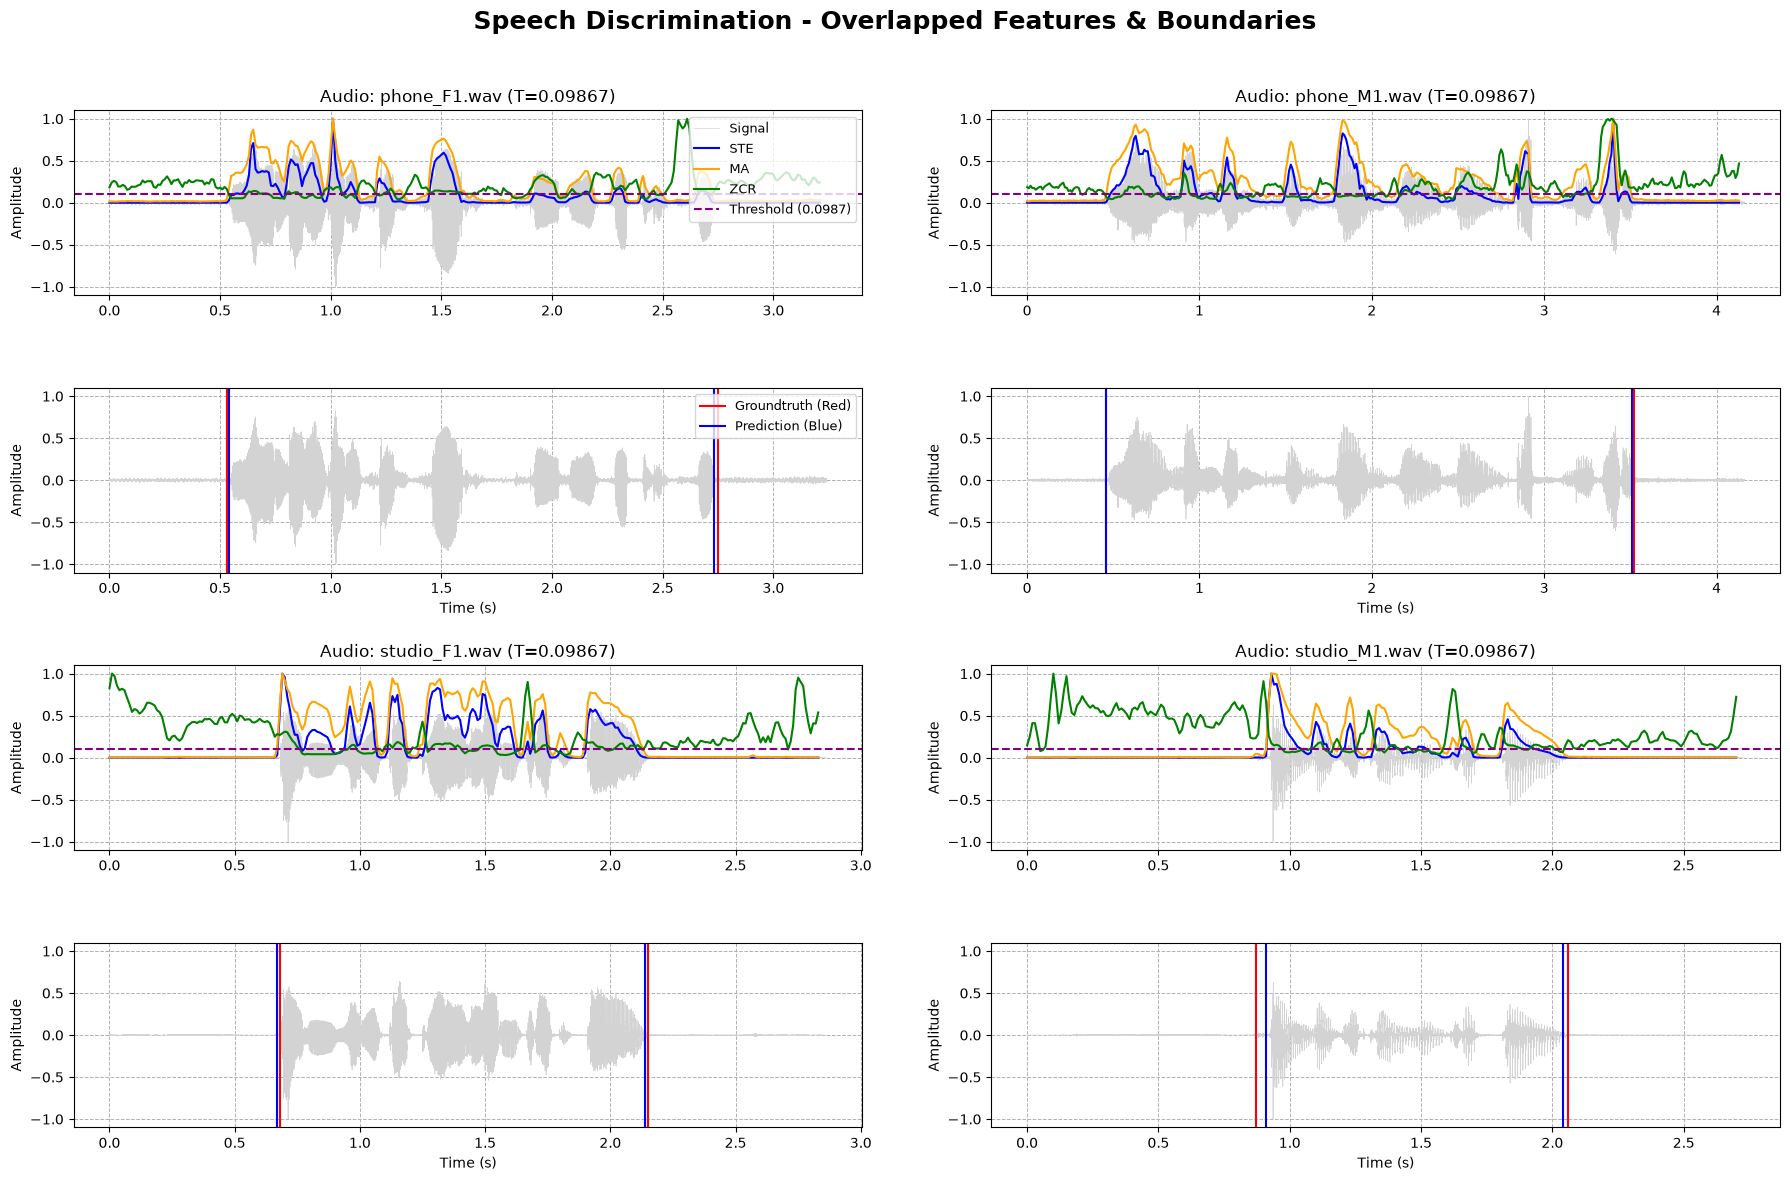

In [7]:
audio_files = [
    "TinHieuHuanLuyen/phone_F1.wav",
    "TinHieuHuanLuyen/phone_M1.wav",
    "TinHieuHuanLuyen/studio_F1.wav",
    "TinHieuHuanLuyen/studio_M1.wav"
]
lab_files = [
    "TinHieuHuanLuyen/phone_F1.lab",
    "TinHieuHuanLuyen/phone_M1.lab",
    "TinHieuHuanLuyen/studio_F1.lab",
    "TinHieuHuanLuyen/studio_M1.lab"
]

TimeAxes, NormalizedSignals, FrameTimeAxes = [], [], []
STEs, MAs, ZCRs, TrueBoundariesList, Filenames = [], [], [], [], []

print("Extracting features from all files...")
for wav_path, lab_path in zip(audio_files, lab_files):
    full_wav_path = os.path.join(parent_dir, wav_path)
    full_lab_path = os.path.join(parent_dir, lab_path)
    filename = full_wav_path.split(os.sep)[-1]
    Filenames.append(filename)

    SignalNormalized, SampleRate, TimeAxis = readAudio(full_wav_path)
    Frames = frameWindow(SignalNormalized, SampleRate)
    STE = calculate_STE(Frames)
    MA = calculate_MA(Frames)
    ZCR = calculate_ZCR(Frames)
    frame_step_seconds = FRAME_STEP / 1000.0
    FrameTimeAxis = np.arange(len(Frames)) * frame_step_seconds

    true_boundaries = read_lab_boundaries(full_lab_path)

    TimeAxes.append(TimeAxis)
    NormalizedSignals.append(SignalNormalized)
    FrameTimeAxes.append(FrameTimeAxis)
    STEs.append(STE)
    MAs.append(MA)
    ZCRs.append(ZCR)
    TrueBoundariesList.append(true_boundaries)

print("Calculating shared threshold...")
shared_T = find_shared_threshold_binary_search(STEs, TrueBoundariesList, FRAME_STEP, MIN_SILENCE)

PredBoundariesList = []
evaluation_results = {}
Titles = []
ThresholdsList = [shared_T] * len(Filenames) 

for i in range(len(Filenames)):
    raw_speech = STEs[i] > shared_T
    detected_speech = smoothingLogic(raw_speech)
    pred_boundaries = get_boundaries_from_bool(detected_speech, frame_step_seconds)
    
    PredBoundariesList.append(pred_boundaries)
    evaluation_results[Filenames[i]] = {'true': TrueBoundariesList[i], 'pred': pred_boundaries}
    Titles.append(f"{Filenames[i]} (T={shared_T:.5f})")

print("="*60)
evaluate_and_print_terminal(evaluation_results, shared_T)

plotFinalFigure(
    TimeAxes, NormalizedSignals, FrameTimeAxes, 
    STEs, MAs, ZCRs, TrueBoundariesList, PredBoundariesList, Titles, ThresholdsList
)